<a href="https://colab.research.google.com/github/HugoCrainich/Statistical-Machine-Learning/blob/main/Homework%201/Econ_3916_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Manual Data Construction
student_basket = [
    {'Item': 'Tuition', 'Price_2016': 45000, 'Price_2024': 58000},
    {'Item': 'Rent (1 Bed)', 'Price_2016': 1200, 'Price_2024': 1800},
    {'Item': 'Chipotle Burrito', 'Price_2016': 7.50, 'Price_2024': 11.50},
    {'Item': 'Texbooks', 'Price_2016': 800, 'Price_2024': 1300},
    ]

In [ ]:
# Define the "Machine" (Function)
def calculate_inflation(base, current):
    return ((current - base) / base) * 100

# Run the Loop
for item in student_basket:
    rate = calculate_inflation(item['Price_2016'], item['Price_2024'])
    print(f"{item['Item']}: {rate:.2f}% Inflation")

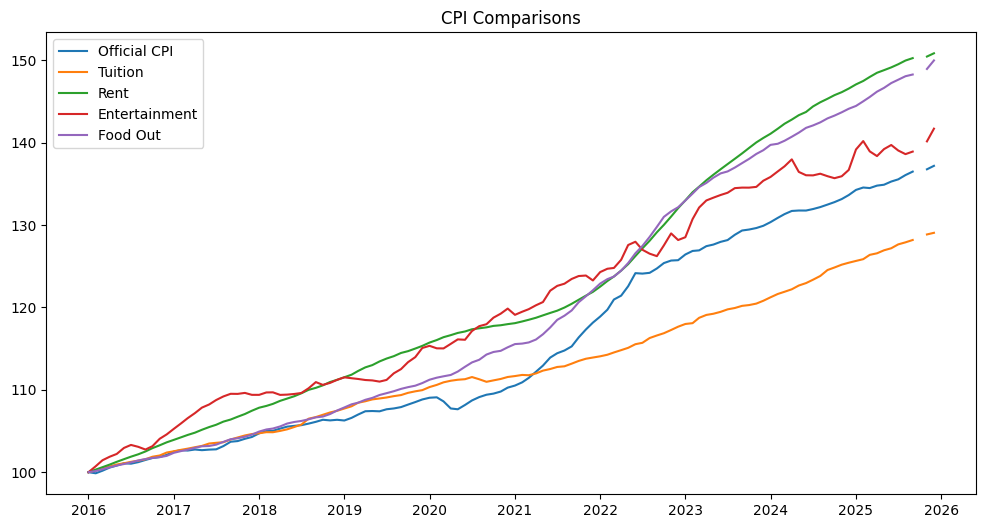

In [28]:
!pip install fredapi
from fredapi import Fred
import pandas as pd
import matplotlib.pyplot as plt
fred = Fred(api_key='57cec9c614c908e7326850bd500dd9e7')

# Fetch Series
official_cpi = fred.get_series('CPIAUCSL')
tuition = fred.get_series('CUSR0000SEEB')
rent = fred.get_series('CUSR0000SEHA')
entertainment = fred.get_series('CUSR0000SERA02')
food_out = fred.get_series('CUSR0000SEFV')

data = pd.DataFrame({'Official CPI': official_cpi,'Tuition': tuition, 'Rent': rent, 'Entertainment': entertainment, "Food Out": food_out})

for columns in data.columns:
  base_value = data.loc["2016-01-01", columns]
  data[columns] = (data[columns] / base_value) * 100

data = data.loc['2016-01-01':]

plt.figure(figsize=(12, 6))
for column in data.columns:
  plt.plot(data.index, data[column], label = column)

plt.legend()
plt.title("CPI Comparisons")
plt.show()

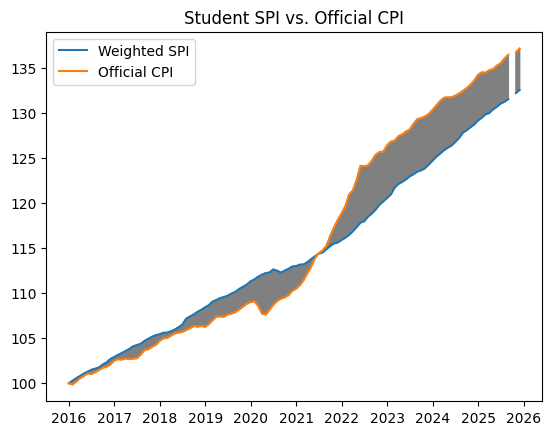

In [29]:
weight_dict = {
    'Tuition': .8,
    'Rent': .1,
    'Entertainment': .09,
    'Food Out': .01
}

data['Student SPI'] = 0

for column, weight in weight_dict.items():
  data['Student SPI'] += data[column] * weight

plt.plot(data.index, data['Student SPI'], label="Weighted SPI")

plt.plot(data.index, data['Official CPI'], label="Official CPI")

plt.fill_between(data.index, data['Student SPI'], data['Official CPI'], color='gray')

plt.legend()

plt.title("Student SPI vs. Official CPI")

plt.show()

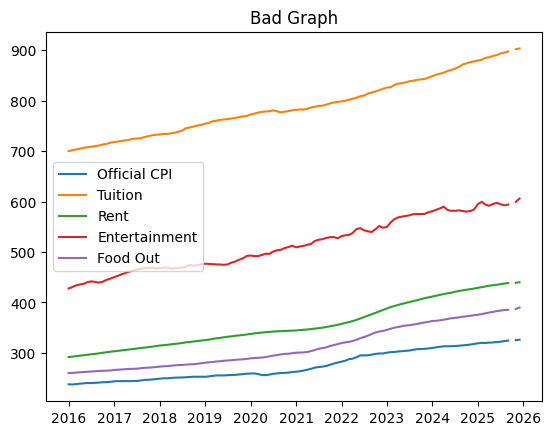

In [30]:
!pip install fredapi
from fredapi import Fred
import pandas as pd
import matplotlib.pyplot as plt
fred = Fred(api_key='57cec9c614c908e7326850bd500dd9e7')

# Fetch Series
raw_official_cpi = fred.get_series('CPIAUCSL')
raw_tuition = fred.get_series('CUSR0000SEEB')
raw_rent = fred.get_series('CUSR0000SEHA')
raw_entertainment = fred.get_series('CUSR0000SERA02')
raw_food_out = fred.get_series('CUSR0000SEFV')

raw_data = pd.DataFrame({'Official CPI': raw_official_cpi,'Tuition': raw_tuition, 'Rent': raw_rent, 'Entertainment': raw_entertainment, "Food Out": raw_food_out})

raw_data = raw_data.loc['2016-01-01':]

for column in raw_data.columns:
  plt.plot(raw_data.index, raw_data[column], label = column)

plt.title("Bad Graph")
plt.legend()
plt.show()

/tmp/ipython-input-2249533090.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['Boston Metro CPI'] = data['Boston Metro CPI'].fillna(method='ffill')


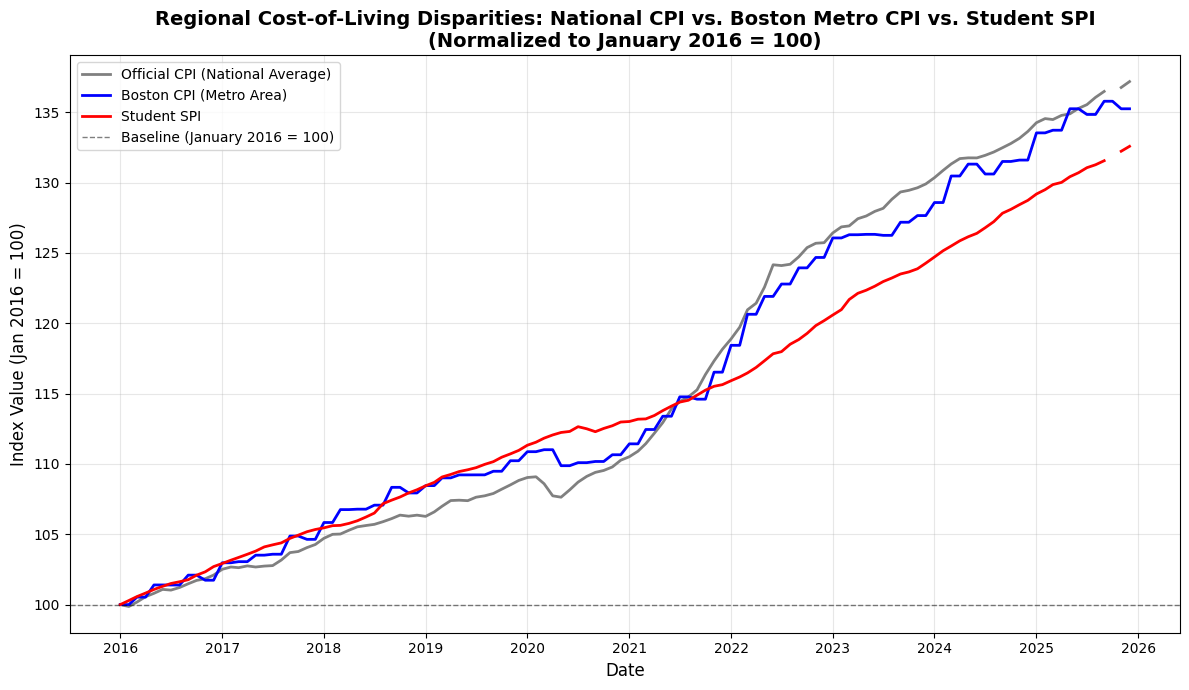


Summary Statistics (2016 onwards):
       Official CPI  Boston Metro CPI  Student SPI
count    119.000000        120.000000   119.000000
mean     115.749209        115.979194   114.507582
std       12.109855         11.255113     9.301157
min       99.867032        100.000000   100.000000
25%      105.665427        106.999397   106.368589
50%      110.264168        111.221935   112.981410
75%      127.795053        126.305231   122.496823
max      137.187989        135.789515   132.584434


In [31]:
from fredapi import Fred
import pandas as pd
import matplotlib.pyplot as plt

# Use your existing FRED API connection
fred = Fred(api_key='57cec9c614c908e7326850bd500dd9e7')

# The FRED series code for Boston-Cambridge-Newton CPI is 'CUURA103SA0'
# This is the CPI-U (All Urban Consumers) for the Boston-Cambridge-Newton area
boston_cpi_code = 'CUURA103SA0'

# Fetch the Boston CPI data
boston_cpi = fred.get_series(boston_cpi_code)

# Convert to DataFrame with a unique column name
boston_df = pd.DataFrame({'Boston Metro CPI': boston_cpi})

# Ensure data index is datetime
data.index = pd.to_datetime(data.index)
boston_df.index = pd.to_datetime(boston_df.index)

# Merge Boston CPI with existing data
data = data.join(boston_df, how='left')

# Fill any missing values using forward fill (in case of date alignment issues)
data['Boston Metro CPI'] = data['Boston Metro CPI'].fillna(method='ffill')

# Normalize Boston CPI to 100 at January 2016
jan_2016_date = pd.Timestamp('2016-01-01')
baseline_value = data.loc[jan_2016_date, 'Boston Metro CPI']
data['Boston Metro CPI'] = (data['Boston Metro CPI'] / baseline_value) * 100

# Filter data to 2016 onwards
data_filtered = data[data.index >= '2016-01-01']

# Create the plot
plt.figure(figsize=(12, 7))

plt.plot(data_filtered.index, data_filtered['Official CPI'],
         color='gray', linewidth=2, label='Official CPI (National Average)')
plt.plot(data_filtered.index, data_filtered['Boston Metro CPI'],
         color='blue', linewidth=2, label='Boston CPI (Metro Area)')
plt.plot(data_filtered.index, data_filtered['Student SPI'],
         color='red', linewidth=2, label='Student SPI')

# Add baseline at 100
plt.axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5,
            label='Baseline (January 2016 = 100)')

# Formatting
plt.xlabel('Date', fontsize=12)
plt.ylabel('Index Value (Jan 2016 = 100)', fontsize=12)
plt.title('Regional Cost-of-Living Disparities: National CPI vs. Boston Metro CPI vs. Student SPI\n(Normalized to January 2016 = 100)',
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# Optional: Display summary statistics
print("\nSummary Statistics (2016 onwards):")
print(data_filtered[['Official CPI', 'Boston Metro CPI', 'Student SPI']].describe())